In [1]:
import numpy as np

In [2]:
T = 1000
x = np.random.normal(0, 1, T)
y = 2 * x + np.random.normal(0, 0.1, T)

In [6]:
#compute estimate on each time step t regresing y_{t-1} on x_{t-1}
beta_offline = np.zeros(T)
M_offline = np.zeros((T, 1, 1))  # covariance matrix
for t in range(2, T):
    X_current = x[1:t].reshape(-1, 1)
    y_current = y[1:t]
    beta_offline[t] = np.linalg.pinv(X_current.T @ X_current) @ X_current.T @ y_current
    M_offline[t-1, :, :] = X_current.T @ X_current / (t - 1)


/var/folders/hb/bc0srnt52zx6lbw4t2k_t_k80000gn/T/ipykernel_19045/1024263079.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  beta_offline[t] = np.linalg.pinv(X_current.T @ X_current) @ X_current.T @ y_current


In [7]:
#compute online estimate using recursive least squares
beta_online = np.zeros(T)
M = np.zeros((T, 1, 1))  # covariance matrix
#initial values
beta_online[0] = 1
beta_online[1] = 1
M[1, :, :] = x[1]**2
for t in range(2, T):
    beta_online[t] = beta_online[t-1] + 1/(t-1) * (M[t-1, :, :])**(-1) * (x[t-1] * (y[t-1] - x[t-1] * beta_online[t-1]))
    M[t, :, :] = M[t-1, :, :] + (1/(t)) * (x[t-1]**2 - M[t-1, :, :])

/var/folders/hb/bc0srnt52zx6lbw4t2k_t_k80000gn/T/ipykernel_19045/3721178888.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  beta_online[t] = beta_online[t-1] + 1/(t-1) * (M[t-1, :, :])**(-1) * (x[t-1] * (y[t-1] - x[t-1] * beta_online[t-1]))


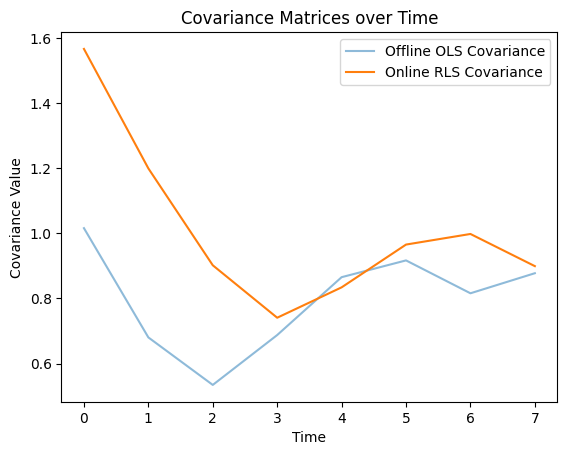

In [11]:
#visualize covariance matrices
plt.plot(M_offline[2:10, 0, 0], label='Offline OLS Covariance', alpha = 0.5)
plt.plot(M[2:10, 0, 0], label='Online RLS Covariance')
plt.legend()
plt.xlabel('Time')  
plt.ylabel('Covariance Value')
plt.title('Covariance Matrices over Time')
plt.show()

Text(0.5, 0, 'Time')

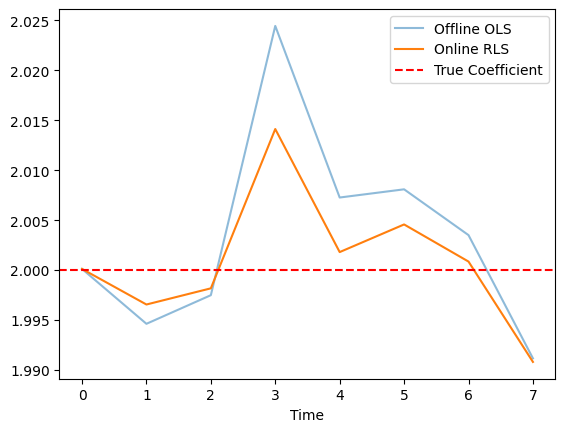

In [8]:
#visualization of coefficients
import matplotlib.pyplot as plt 
plt.plot(beta_offline[2:10], label='Offline OLS', alpha = 0.5)
plt.plot(beta_online[2:10], label='Online RLS')
plt.axhline(y=2, color='r', linestyle='--', label='True Coefficient')
plt.legend()
plt.xlabel('Time')  

In [33]:
T = 30
M_offline = np.zeros(T)
M_online = np.zeros(T)
x_tminus1 = np.random.normal(0,1,T)
for t in range(1, T):
    M_offline[t] = 1 / t * np.sum(x_tminus1[:t])
    M_online[t] = M_online[t-1] + 1 / t * (x_tminus1[t-1] - M_online[t-1])

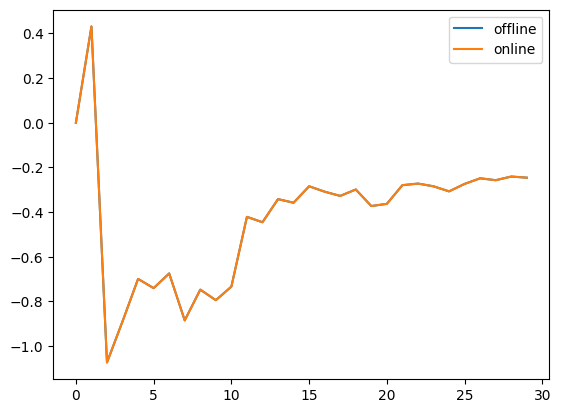

In [36]:
plt.plot(M_offline, label = "offline")
plt.plot(M_online, label = "online")
plt.legend()
plt.show()